# 03 — Annotation and biological interpretation

This notebook interprets clustered single-cell RNA-seq data by identifying marker genes and assigning biological identities to clusters.

In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd

## Load data

In [2]:
adata = sc.read("../data/processed/adata_clustered.h5ad")
adata

AnnData object with n_obs × n_vars = 2638 × 1826
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## Inspect marker genes

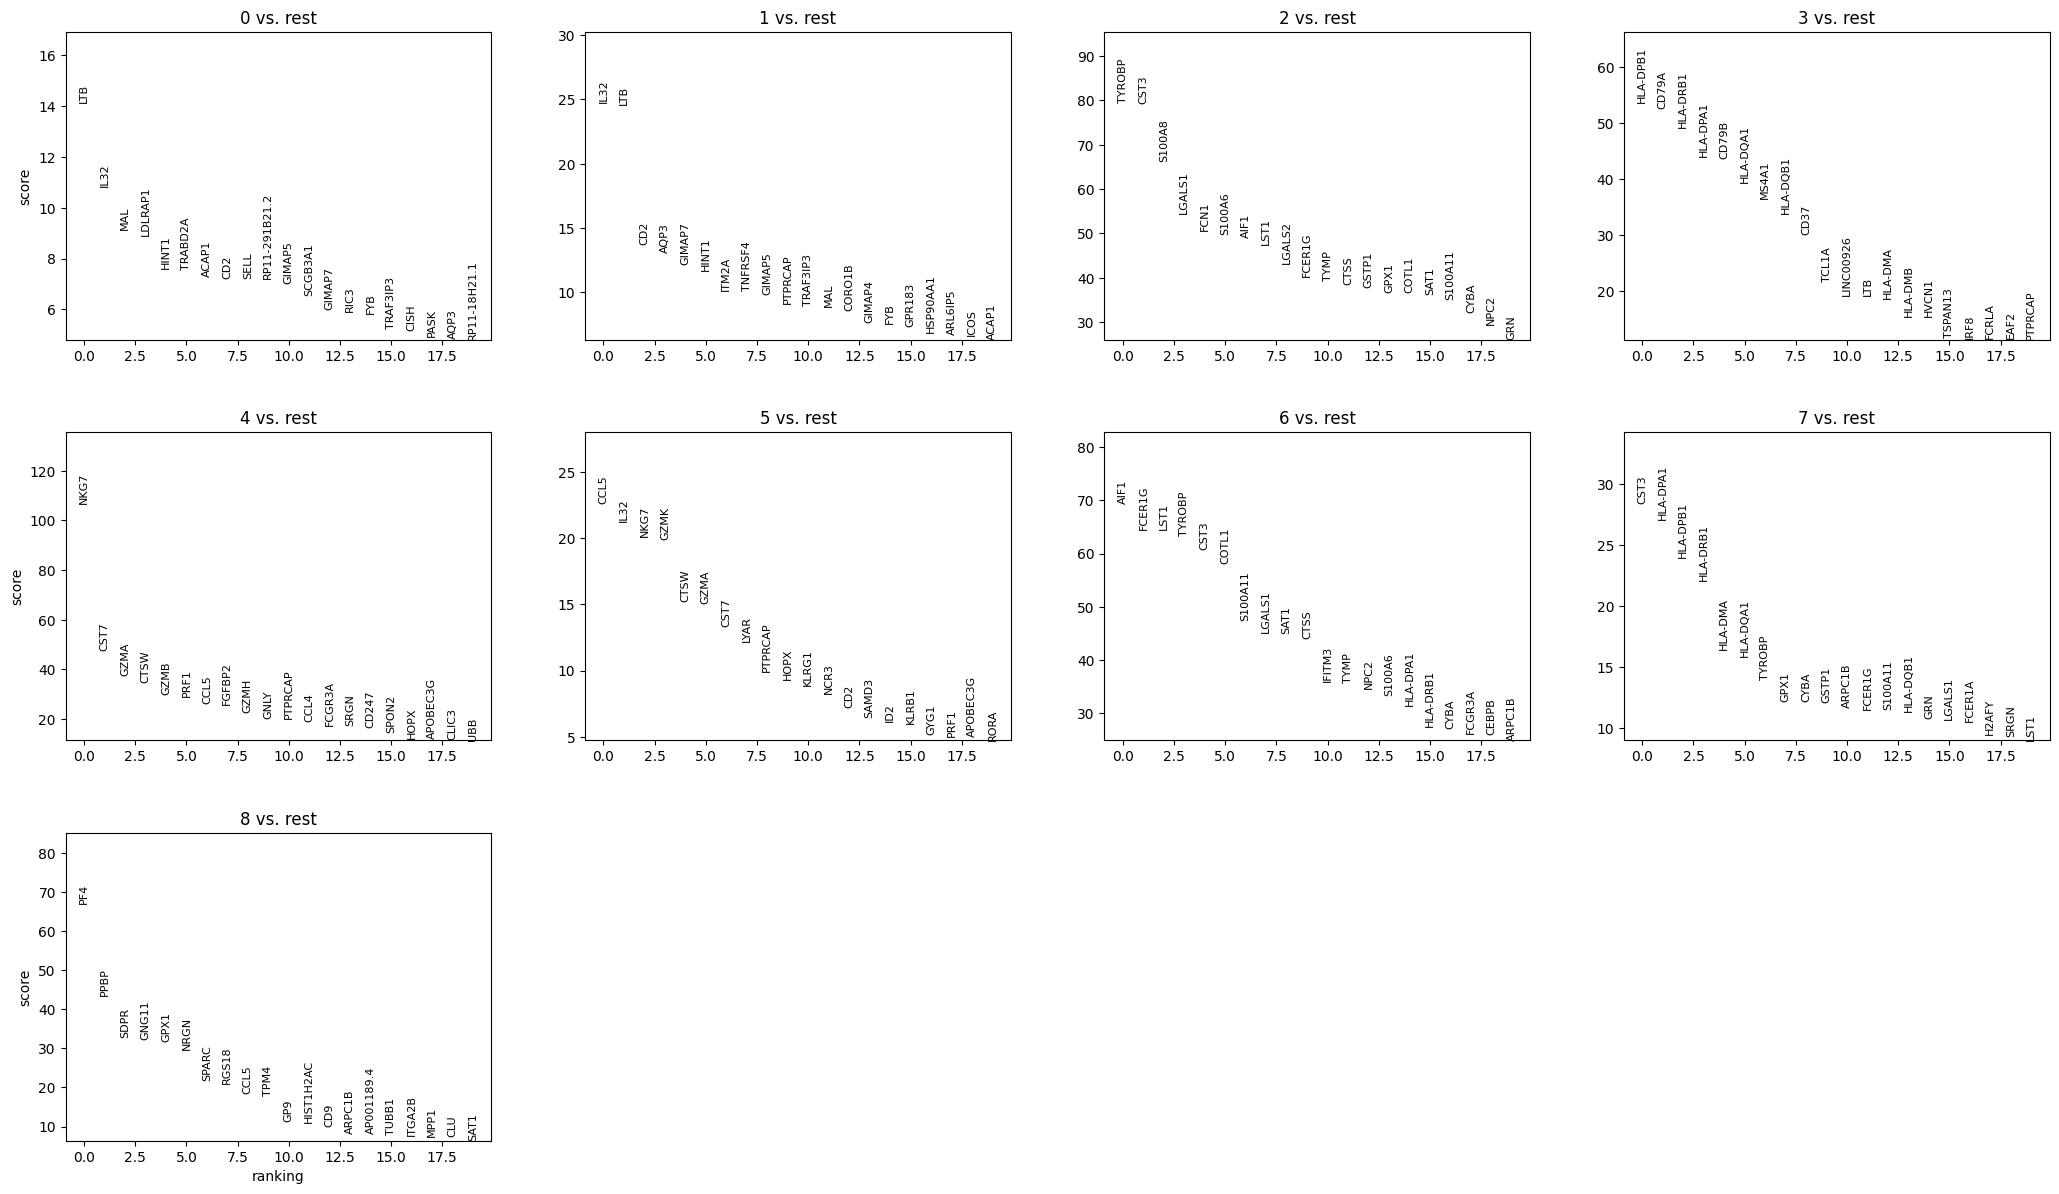

In [4]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

This is what we seen before. I want to extract them as a table, and then filter by top 5 marker genes for each group.

In [5]:
marker_df = sc.get.rank_genes_groups_df(adata, group=None)
marker_df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LTB,14.128648,NaN,2.171001e-42,8.090301e-41
1,0,IL32,10.820608,NaN,4.051106e-26,8.702730e-25
2,0,MAL,9.133795,NaN,5.652073e-19,9.829223e-18
3,0,LDLRAP1,8.900613,NaN,3.999899e-18,6.521264e-17
4,0,HINT1,7.600488,NaN,6.486943e-14,8.460827e-13


In [6]:
top_markers = marker_df.groupby("group").head(5)
top_markers

/var/folders/3_/pdsgzgb17hg6fszr5spc0gz80000gq/T/ipykernel_6146/4015092078.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_markers = marker_df.groupby("group").head(5)


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LTB,14.128648,NaN,2.171001e-42,8.090301e-41
1,0,IL32,10.820608,NaN,4.051106e-26,8.702730e-25
2,0,MAL,9.133795,NaN,5.652073e-19,9.829223e-18
3,0,LDLRAP1,8.900613,NaN,3.999899e-18,6.521264e-17
4,0,HINT1,7.600488,NaN,6.486943e-14,8.460827e-13
1826,1,IL32,24.722448,NaN,1.071977e-107,3.914859e-105
1827,1,LTB,24.592833,NaN,4.538599e-108,2.071871e-105
1828,1,CD2,13.662386,NaN,8.470221e-38,3.772347e-36
1829,1,AQP3,13.101709,NaN,1.060488e-34,4.303223e-33
1830,1,GIMAP7,12.118645,NaN,3.530511e-31,1.289342e-29


## Labels assignment

In [ ]:
# work in progress
cluster_labels = {
    "0": "T cells",
    "1": "T cells (possibly activated or subtype)",
    "2": "Monocytes",
    "3": "B Cells",
    "4": "Cytotoxic T cells",
    "5": "Cytotoxic T cells (different subtype)",
    "6": "Monocytes / macrophage-like",
    "7": "Dendritic cells / APCs",
    "8": "Platelets"
}

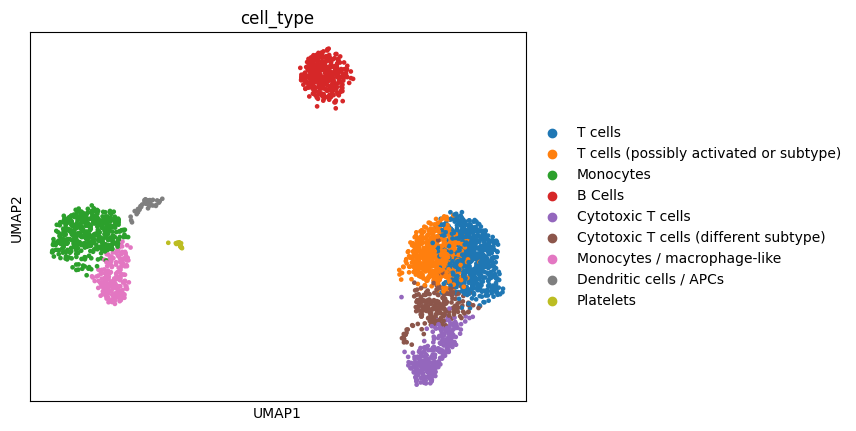

In [9]:
adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_labels)

sc.pl.umap(adata, color=["cell_type"])

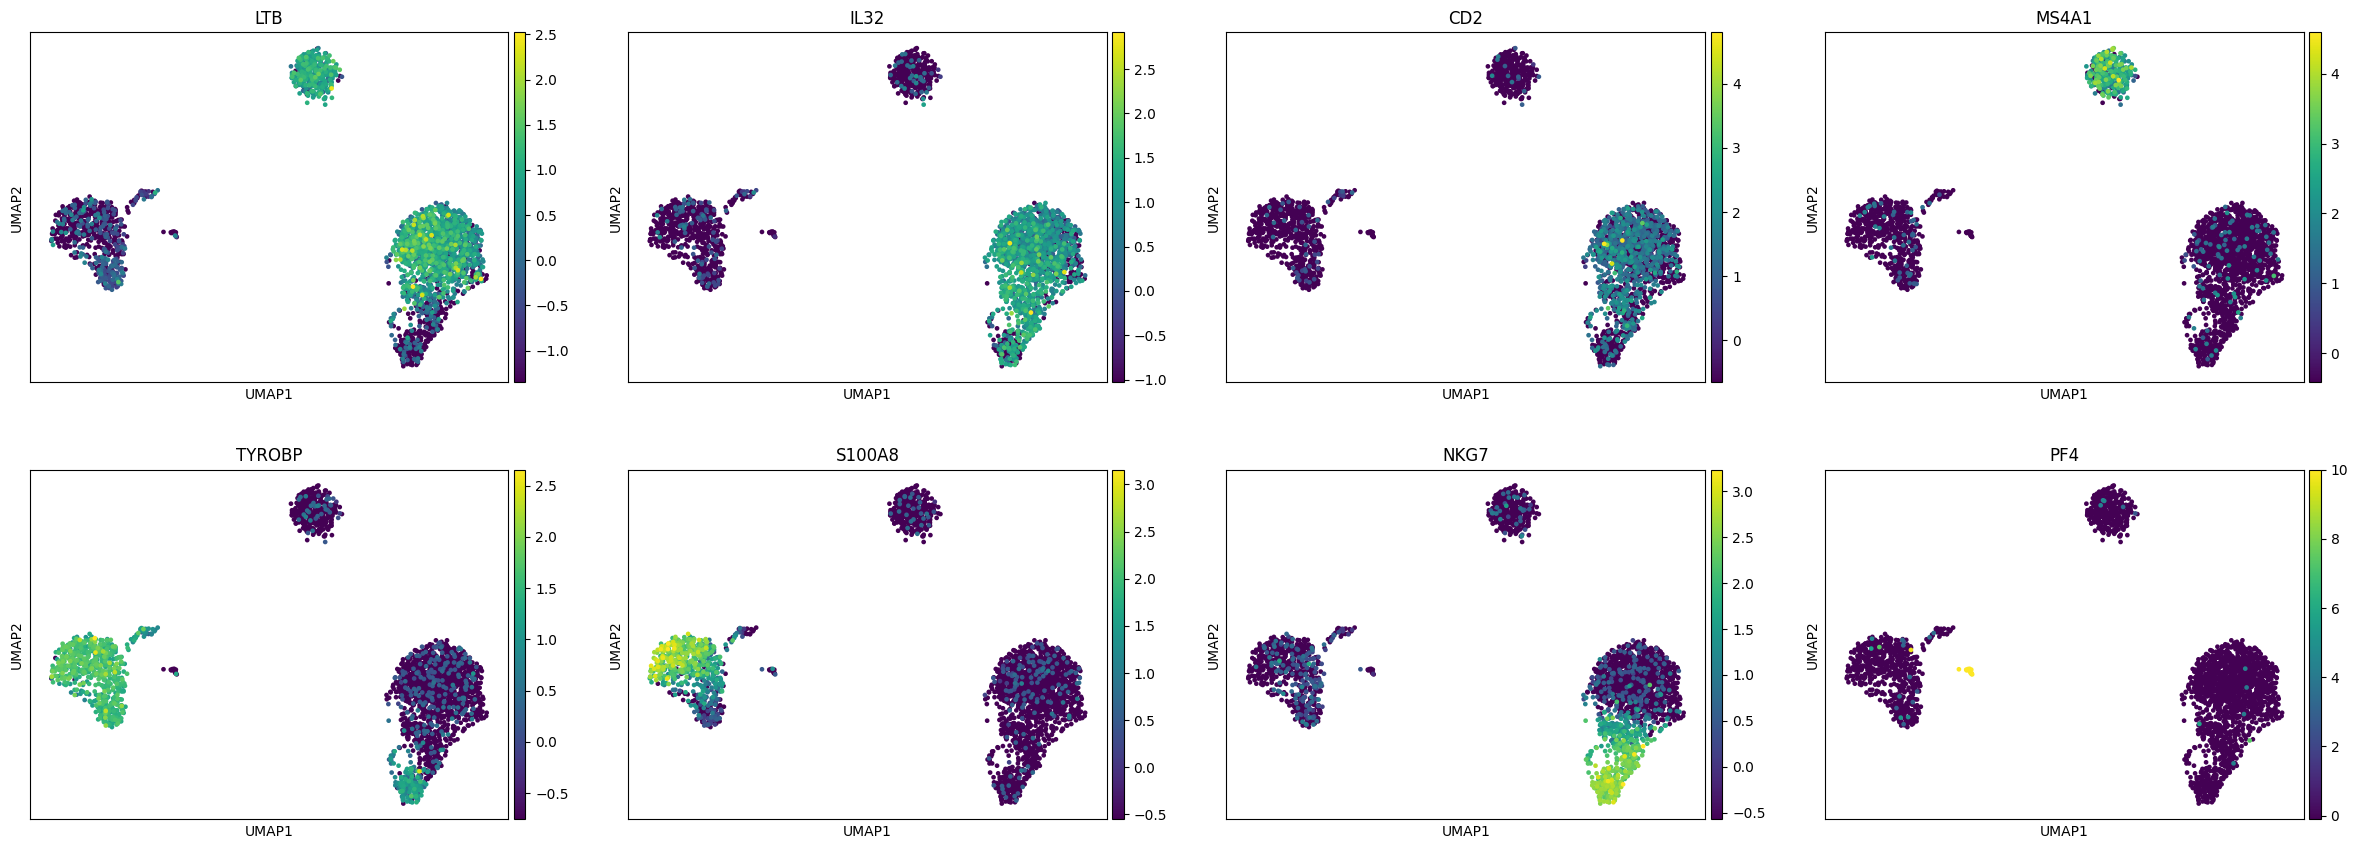

In [14]:
sc.pl.umap(
    adata,
    color=["LTB", "IL32", "CD2", "MS4A1", "TYROBP", "S100A8", "NKG7", "PF4"],
)

In [13]:
adata.write("../data/processed/adata_annotated.h5ad")